# MOS Inference Notebook

This notebook loads a previously saved model checkpoint and predicts MOS scores for **new images**.

Expected saved model from the training notebook:

- `outputs_resnet18_mos/best_model.pth`

How to use:
1. Put your new images into a folder, for example `new_images/`
2. Update `NEW_IMAGE_DIR` if needed
3. Run all cells


In [1]:
# Optional: install packages if needed
# %pip install -q torch torchvision pandas pillow matplotlib


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import transforms, models

# =========================
# User-adjustable settings
# =========================
MODEL_PATH = Path("outputs_resnet18_mos/best_model.pth")
NEW_IMAGE_DIR = Path("new_images")              # put new images here
SAVE_CSV_PATH = Path("new_image_predictions.csv")

IMAGE_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model checkpoint not found: {MODEL_PATH.resolve()}")

if not NEW_IMAGE_DIR.exists():
    raise FileNotFoundError(f"New image folder not found: {NEW_IMAGE_DIR.resolve()}")

print("MODEL_PATH   :", MODEL_PATH.resolve())
print("NEW_IMAGE_DIR:", NEW_IMAGE_DIR.resolve())

class ResNet18MOSRegressor(nn.Module):
    # Output is mapped to [1, 5] with sigmoid.
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=0.2),
            nn.Linear(in_features, 1)
        )

    def forward(self, x):
        raw = self.backbone(x).squeeze(1)
        pred = 1.0 + 4.0 * torch.sigmoid(raw)
        return pred

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

def load_model(model_path, device):
    ckpt = torch.load(model_path, map_location=device)
    model = ResNet18MOSRegressor().to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model, ckpt

def predict_one(model, image_path, device):
    image = Image.open(image_path).convert("RGB")
    x = eval_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(x).item()
    return float(pred)

def gather_image_paths(folder):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
    paths = sorted([p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in exts])
    return paths

model, ckpt = load_model(MODEL_PATH, DEVICE)
print(f"Checkpoint loaded. Saved epoch: {ckpt.get('epoch', 'unknown')}")
print("Checkpoint config:")
print(ckpt.get("config", {}))


Device: cuda
MODEL_PATH   : /home/sagemaker-user/outputs_resnet18_mos/best_model.pth
NEW_IMAGE_DIR: /home/sagemaker-user/new_images
Checkpoint loaded. Saved epoch: 14
Checkpoint config:
{'image_dir': 'dataset_extracted/512x384', 'csv_path': 'dataset_extracted/koniq10k_scores_and_distributions.csv', 'output_dir': 'outputs_resnet18_mos', 'random_seed': 42, 'train_ratio': 0.8, 'val_ratio': 0.1, 'test_ratio': 0.1, 'image_size': 224, 'batch_size': 16, 'num_workers': 0, 'phase1_epochs': 3, 'phase2_epochs': 12, 'lr_phase1': 0.0003, 'lr_phase2': 0.0001, 'weight_decay': 0.0001, 'early_stopping_patience': 5, 'target_col': 'MOS', 'model_name': 'resnet18_mos_regression', 'device': 'cuda'}


Saved predictions to: /home/sagemaker-user/new_image_predictions.csv


,image_path,image_name,predicted_MOS
0,new_images/image-4.webp,image-4.webp,3.801484
1,new_images/image-5.webp,image-5.webp,3.577754
2,new_images/image-6.jpg,image-6.jpg,2.901058
3,new_images/image-7.jpg,image-7.jpg,2.885227
4,new_images/image-2.webp,image-2.webp,1.564470


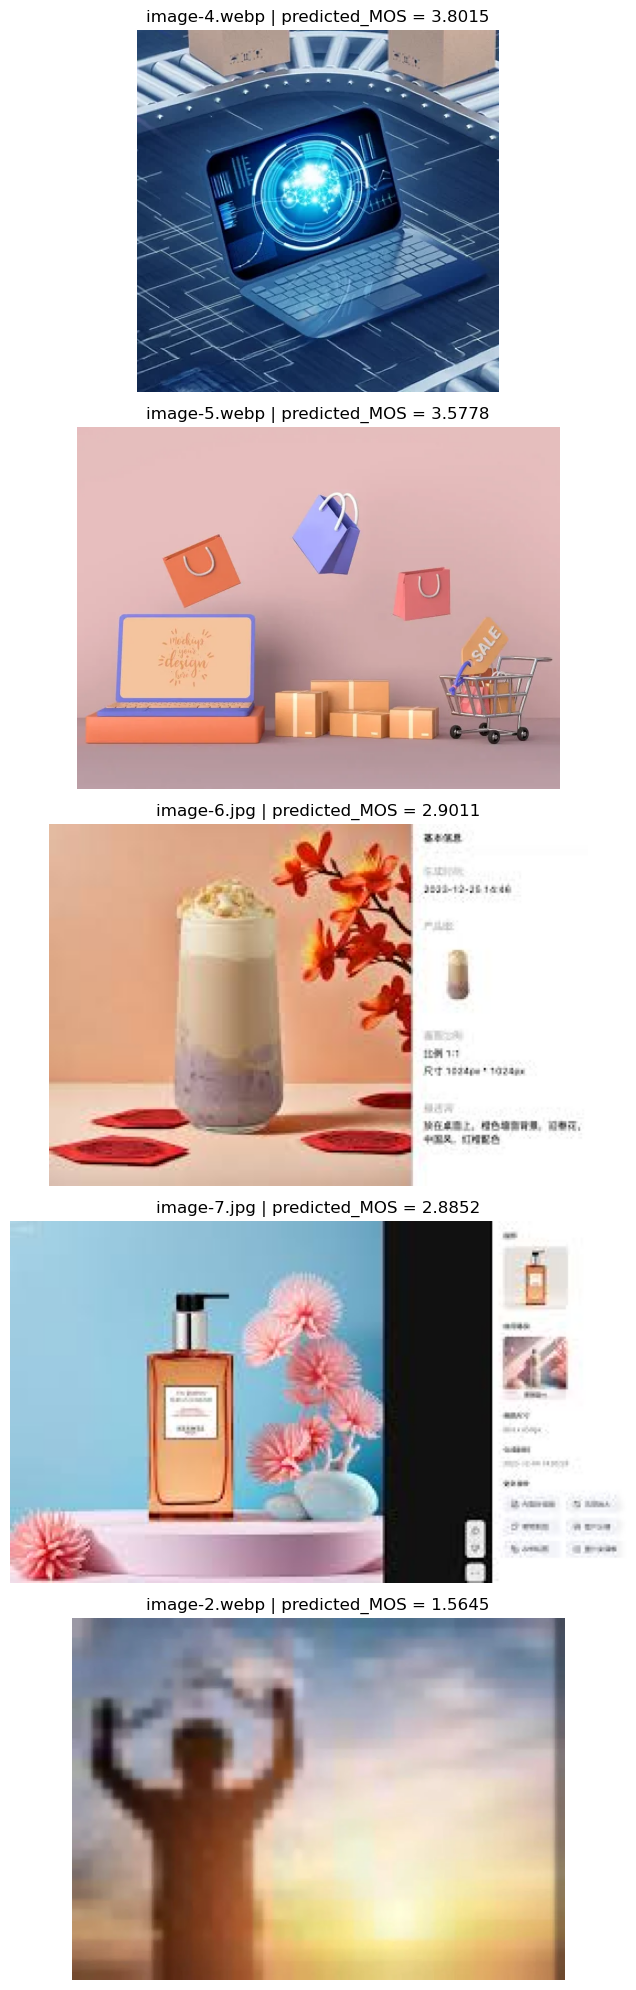

In [5]:
image_paths = gather_image_paths(NEW_IMAGE_DIR)

if not image_paths:
    raise FileNotFoundError(f"No images found under: {NEW_IMAGE_DIR.resolve()}")

rows = []
for p in image_paths:
    score = predict_one(model, p, DEVICE)
    rows.append({
        "image_path": str(p),
        "image_name": p.name,
        "predicted_MOS": score
    })

pred_df = pd.DataFrame(rows).sort_values("predicted_MOS", ascending=False).reset_index(drop=True)
pred_df.to_csv(SAVE_CSV_PATH, index=False)

print(f"Saved predictions to: {SAVE_CSV_PATH.resolve()}")
display(pred_df)

# show a few preview images
n_show = min(5, len(pred_df))
fig, axes = plt.subplots(n_show, 1, figsize=(8, 4 * n_show))
if n_show == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, pred_df.head(n_show).iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"{row['image_name']} | predicted_MOS = {row['predicted_MOS']:.4f}")
    ax.axis("off")

plt.tight_layout()
plt.show()